In [ ]:
import matplotlib.pyplot as plt
from models import *
import torch.optim as optim

In [2]:
path_to_data = "data/microbial_time_series"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = MicrobTimeSeriesDataset(path_to_data, device=device)

In [3]:
train_dataset, validation_dataset = torch.utils.data.random_split(dataset, [45, 5])

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=5,        
    shuffle=True,         
    pin_memory=False if device == 'cuda' else "cpu"     
)

validation_dataloader = torch.utils.data.DataLoader(
    validation_dataset,
    batch_size=5,          
    shuffle=False,        
    pin_memory=False if device == 'cuda' else "cpu"     
)

In [4]:
microb_multi_net = MicrobMultiNet(
    input_dim=10,
    hidden_layers=1,
    hidden_width=5,
    activation="tanh"
)
dim_state_latent = 0
hybrid_ode = HybridODE(input_dim=10,        
        dim_state_latent=dim_state_latent,  
        use_lotka_volterra=False,
        use_nn_markovian=True,
        use_nn_non_markovian=False,
        num_hidden_layers=2,
        hidden_width=30,
        activation="tanh"
        )

# choose the model to be used 
func = microb_multi_net


In [7]:
# training params
method = "euler"

rtol = 1e-5 # only usefull if using another numerical integrator
atol = 1e-7 # only usefull if using another numerical integrator
 

optimizer = optim.Adam(func.parameters(), lr=0.005)
lambda_mask = 0.000015
t_tensor = torch.FloatTensor(np.linspace(1,70, 150))



In [8]:
losses = []
func.train()
for epoch in range(400):
    loss_reached = False
    for batch in train_dataloader:
        optimizer.zero_grad()



        initial_state1 = batch[:, 0, :].squeeze(1)
        initial_state1 = torch.nn.functional.pad(initial_state1, (0, dim_state_latent))
        tensor_1 = t_tensor[:72]

        inital_state2 = batch[:, 72, :].squeeze(1)
        inital_state2 = torch.nn.functional.pad(inital_state2, (0, dim_state_latent))
        tensor_2 = t_tensor[72:]
        
  

        pred_y1 = odeint(func, initial_state1, tensor_1, method=method, rtol=rtol,atol=atol)
        pred_y2 = odeint(func, inital_state2, tensor_2, method=method, rtol=rtol,atol=atol)



        pred_y = torch.cat((pred_y1, pred_y2), dim=0)


        pred_y = pred_y.permute(1, 0, 2)
        pred_y = pred_y[:, :, :10]
        



        loss = torch.mean((pred_y - batch) ** 2)


        if lambda_mask > 0 & (epoch > 200):
             l1_norm_mask = func.mask.abs().sum()
             loss += lambda_mask * l1_norm_mask

             
 
        
        loss.backward()
        #clip_grad_norm_(func.parameters(), max_norm=4)
        optimizer.step()
        losses.append(loss.item())

    if epoch % 30 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.0009392013889737427
Epoch 30, Loss: 0.0002942497958429158
Epoch 60, Loss: 0.00030871061608195305
Epoch 90, Loss: 0.00019696931121870875
Epoch 120, Loss: 0.00020829765708185732
Epoch 150, Loss: 0.00022580233053304255
Epoch 180, Loss: 0.0002099379780702293
Epoch 210, Loss: 0.0002281488268636167
Epoch 240, Loss: 0.0002092408249154687
Epoch 270, Loss: 0.00019608736329246312
Epoch 300, Loss: 0.00023503554984927177
Epoch 330, Loss: 0.00021812251361552626
Epoch 360, Loss: 0.0002137681731255725
Epoch 390, Loss: 0.00019252013589721173


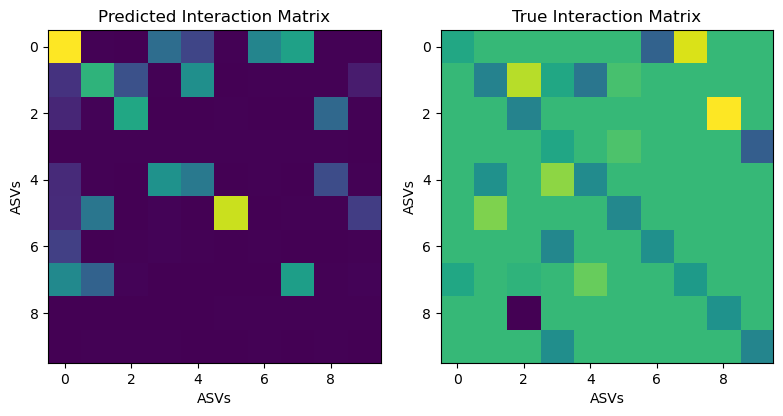

In [9]:
pred = func.mask.detach().numpy()
true = glv_params = np.load("/Users/leoganser/Desktop/NeuralODE/data/glv_params.npy")

# Use the same color scale for both


fig, axes = plt.subplots(1, 2, figsize=(8, 4))

im0 = axes[0].imshow(pred)
axes[0].set_title("Predicted Interaction Matrix")
axes[0].set_xlabel("ASVs")
axes[0].set_ylabel("ASVs")

im1 = axes[1].imshow(true)
axes[1].set_title("True Interaction Matrix")
axes[1].set_xlabel("ASVs")
axes[1].set_ylabel("ASVs")



plt.tight_layout()
plt.show()

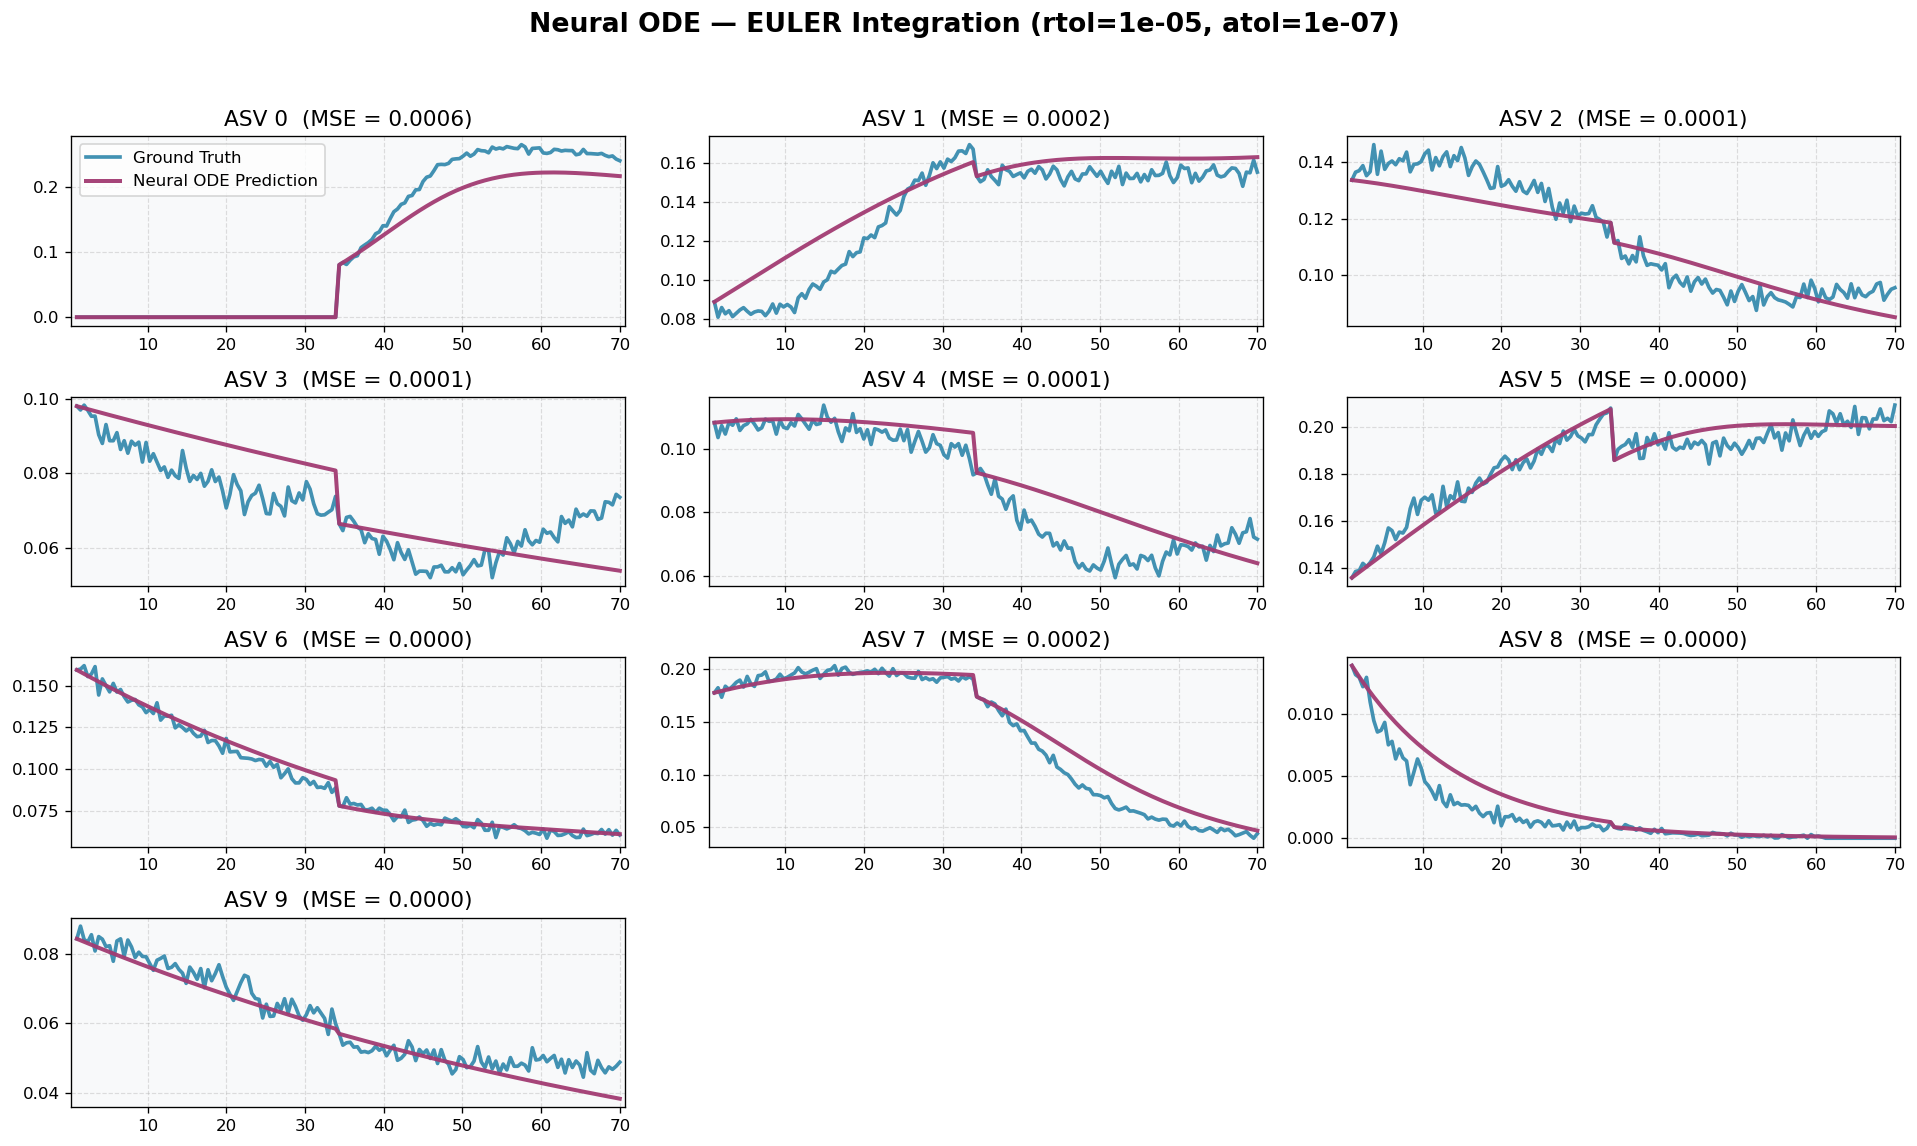

(<Figure size 1920x1200 with 12 Axes>,
 array([<Axes: title={'center': 'ASV 0  (MSE = 0.0006)'}>,
        <Axes: title={'center': 'ASV 1  (MSE = 0.0002)'}>,
        <Axes: title={'center': 'ASV 2  (MSE = 0.0001)'}>,
        <Axes: title={'center': 'ASV 3  (MSE = 0.0001)'}>,
        <Axes: title={'center': 'ASV 4  (MSE = 0.0001)'}>,
        <Axes: title={'center': 'ASV 5  (MSE = 0.0000)'}>,
        <Axes: title={'center': 'ASV 6  (MSE = 0.0000)'}>,
        <Axes: title={'center': 'ASV 7  (MSE = 0.0002)'}>,
        <Axes: title={'center': 'ASV 8  (MSE = 0.0000)'}>,
        <Axes: title={'center': 'ASV 9  (MSE = 0.0000)'}>, <Axes: >,
        <Axes: >], dtype=object))

In [10]:
plot_results(dataset=validation_dataset[0], func=func, t=t_tensor, augment_dim=0, method="euler", rtol=1e-5, atol=1e-7)